# Logistic Regression from Scratch — Gradient Descent Walkthrough

**Goal:** start from *randomly initialised* weights and use gradient descent to arrive at the optimal weight values for a 5-feature **binary classification** problem.

We'll:
1. Generate a well-posed dataset with **5 features** and a **binary target** (0/1)
2. Randomly initialise the weights
3. Implement the sigmoid function, the cost function (binary cross-entropy), and its gradients
4. Run gradient descent and watch the loss decrease
5. Convert the learned weights back to the original feature scale and compare them to the **true weights** used to generate the data
6. Cross-check against scikit-learn's `LogisticRegression`
7. Evaluate with classification metrics: accuracy, confusion matrix, decision boundary behaviour

> **How this differs from linear regression:** the model output is squeezed through a **sigmoid** so it represents a probability between 0 and 1, the cost function is **binary cross-entropy** instead of MSE, and — unlike linear regression — there's **no closed-form solution** to check against. We use scikit-learn as the cross-check instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. The Dataset

5 features $x_1, \dots, x_5$, 200 samples. We generate a binary label by first computing a linear score from **known true weights**, passing it through the sigmoid to get a probability, then drawing a 0/1 outcome from that probability (like flipping a biased coin):

$$z = 1.2x_1 - 0.8x_2 + 0.5x_3 + 1.0x_4 - 1.5x_5 - 3.0 \qquad p = \sigma(z) \qquad y \sim \text{Bernoulli}(p)$$

Knowing the true weights in advance lets us check that gradient descent recovers something close to them — the standard way to sanity-check a from-scratch implementation.

We use **200 samples** (well more than the 5 features + bias = 6 parameters) so the problem is well-posed, and enough samples that the random Bernoulli draws don't swamp the signal.

In [2]:
rng = np.random.default_rng(42)

n_samples, n_features = 200, 5

X = rng.uniform(0, 10, size=(n_samples, n_features)).round(2)

true_w = np.array([1.2, -0.8, 0.5, 1.0, -1.5])
true_b = -3.0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_true = X @ true_w + true_b
p_true = sigmoid(z_true)
y = (rng.uniform(size=n_samples) < p_true).astype(int)

feature_names = [f"x{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df["y"] = y
df.head(10)

,x1,x2,x3,x4,x5,y
0,7.74,4.39,8.59,6.97,0.94,1
1,9.76,7.61,7.86,1.28,4.50,1
2,3.71,9.27,6.44,8.23,4.43,1
3,2.27,5.55,0.64,8.28,6.32,0
4,7.58,3.55,9.71,8.93,7.78,1
5,1.95,4.67,0.44,1.54,6.83,0
6,7.45,9.68,3.26,3.70,4.70,0
7,1.89,1.30,4.76,2.27,6.70,0
8,4.37,8.33,7.00,3.12,8.32,0
9,8.05,3.87,2.88,6.82,1.40,1


In [3]:
print("Class balance (fraction of y=1):", y.mean().round(3))
df.describe()

Class balance (fraction of y=1): 0.43


,x1,x2,x3,x4,x5,y
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5.023100,5.292800,4.852000,4.757900,4.933550,0.430000
std,2.820701,2.869207,3.049826,2.788821,3.040928,0.496318
min,0.020000,0.050000,0.020000,0.010000,0.050000,0.000000
25%,2.530000,2.935000,1.970000,2.232500,2.070000,0.000000
50%,4.920000,5.055000,4.935000,4.795000,5.140000,0.000000
75%,7.425000,7.962500,7.802500,6.980000,7.697500,1.000000
max,9.950000,9.800000,9.990000,9.930000,9.990000,1.000000


## 2. Train / Test Split

In [4]:
def train_test_split(X, y, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_test = int(len(X) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_frac=0.2, seed=0)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (160, 5)  Test: (40, 5)


## 3. Feature Standardisation

Same reasoning as in linear regression: unscaled features make gradient descent slow and uneven across weights. Standardise using statistics from the **training set only**.

In [5]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("Feature means (train, standardized):", X_train_s.mean(axis=0))
print("Feature stds  (train, standardized):", X_train_s.std(axis=0))

Feature means (train, standardized): [ 0.  0.  0.  0. -0.]
Feature stds  (train, standardized): [1. 1. 1. 1. 1.]


## 4. Random Weight Initialisation

In [6]:
rng_init = np.random.default_rng(7)   # separate RNG just for weight init

w = rng_init.normal(loc=0.0, scale=1.0, size=n_features)
b = 0.0

print("Randomly initialised weights:", w)
print("Randomly initialised bias:   ", b)

Randomly initialised weights: [ 0.0012  0.2987 -0.2741 -0.8906 -0.4547]
Randomly initialised bias:    0.0


## 5. Model, Cost Function, and Gradients

**Model.** A linear score passed through the sigmoid to produce a probability:

$$\hat{p} = \sigma(Xw + b) = \frac{1}{1 + e^{-(Xw+b)}}$$

**Cost — Binary Cross-Entropy (log loss).** Measures how far the predicted probability is from the true label, penalising confident wrong predictions heavily:

$$L(w, b) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i\log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big]$$

**Gradients.** Remarkably, differentiating this cost through the sigmoid gives a formula with the *exact same shape* as linear regression's gradient — only $\hat{y}$ is replaced by $\hat{p}$:

$$\frac{\partial L}{\partial w} = \frac{1}{m}X^{T}(\hat{p} - y) \qquad \frac{\partial L}{\partial b} = \frac{1}{m}\sum(\hat{p}_i - y_i)$$

(This isn't a coincidence — it's a special property of pairing the sigmoid with cross-entropy loss; the messy chain-rule terms from differentiating $\sigma$ and $\log$ cancel out neatly.)

In [7]:
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def compute_loss(X, y, w, b, eps=1e-9):
    p = predict_proba(X, w, b)
    p = np.clip(p, eps, 1 - eps)   # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def compute_gradients(X, y, w, b):
    m = len(y)
    p = predict_proba(X, w, b)
    error = p - y
    grad_w = (1 / m) * (X.T @ error)
    grad_b = (1 / m) * np.sum(error)
    return grad_w, grad_b

print("Initial training loss:", compute_loss(X_train_s, y_train, w, b))

Initial training loss: 0.8664493536215112


## 6. Gradient Descent Loop

In [8]:
def gradient_descent(X, y, w, b, lr=0.5, epochs=3000, log_every=250):
    history = []
    for epoch in range(epochs):
        grad_w, grad_b = compute_gradients(X, y, w, b)
        w = w - lr * grad_w
        b = b - lr * grad_b
        if epoch % log_every == 0 or epoch == epochs - 1:
            history.append((epoch, compute_loss(X, y, w, b)))
    return w, b, history

w_final, b_final, history = gradient_descent(
    X_train_s, y_train, w.copy(), b, lr=0.5, epochs=3000, log_every=250
)

print("Learned weights (standardized space):", w_final)
print("Learned bias    (standardized space):", b_final)

Learned weights (standardized space): [ 4.2683 -2.8427  1.7859  3.6154 -6.1597]
Learned bias    (standardized space): -1.0099927697959392


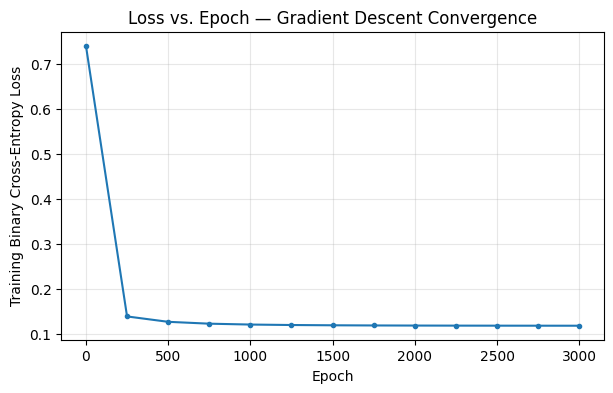

In [9]:
epochs_logged, losses_logged = zip(*history)

plt.figure(figsize=(7, 4))
plt.plot(epochs_logged, losses_logged, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Binary Cross-Entropy Loss")
plt.title("Loss vs. Epoch — Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.show()

## 7. Convert Weights Back to the Original (Unstandardised) Scale

Same conversion as in linear regression — it only depends on the model being *linear inside* the nonlinearity ($Xw+b$), which is still true here since the sigmoid is applied afterward:

$$w_{orig} = \frac{w_{std}}{\sigma} \qquad b_{orig} = b_{std} - \sum \frac{w_{std} \cdot \mu}{\sigma}$$

In [10]:
w_orig = w_final / sigma
b_orig = b_final - np.sum(w_final * mu / sigma)

comparison = pd.DataFrame({
    "feature": feature_names,
    "true_weight": true_w,
    "learned_weight (gradient descent)": w_orig,
})
print(comparison.to_string(index=False))
print(f"\ntrue_bias = {true_b:.4f}   learned_bias = {b_orig:.4f}")

feature  true_weight  learned_weight (gradient descent)
     x1          1.2                           1.556310
     x2         -0.8                          -1.011704
     x3          0.5                           0.587130
     x4          1.0                           1.272319
     x5         -1.5                          -1.994702

true_bias = -3.0000   learned_bias = -3.0485


## 8. Check Against scikit-learn

Unlike linear regression, logistic regression has **no closed-form solution** — the cross-entropy loss can't be minimised by solving a system of linear equations, so it always needs an iterative method like gradient descent (or the equivalents scikit-learn uses internally). We cross-check against `LogisticRegression` with regularisation turned off, so it's solving the exact same unregularised problem we are.

In [11]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(C=1e6, max_iter=2000)   # C very large -> effectively no regularisation
sk_model.fit(X_train, y_train)

sk_comparison = pd.DataFrame({
    "feature": feature_names + ["bias"],
    "gradient_descent_weight": np.append(w_orig, b_orig),
    "sklearn_weight": np.append(sk_model.coef_.ravel(), sk_model.intercept_[0]),
})
print(sk_comparison.to_string(index=False))

feature  gradient_descent_weight  sklearn_weight
     x1                 1.556310        1.622291
     x2                -1.011704       -1.058829
     x3                 0.587130        0.612841
     x4                 1.272319        1.327517
     x5                -1.994702       -2.079077
   bias                -3.048522       -3.153324


## 9. Evaluate on the Held-Out Test Set

For classification we care about more than the loss value — accuracy and the confusion matrix tell us how the model performs at the decision-making task itself.

In [12]:
def predict_class(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

y_pred_test = predict_class(X_test_s, w_final, b_final)

accuracy = (y_pred_test == y_test).mean()
print(f"Test accuracy: {accuracy:.4f}")

# confusion matrix, built by hand
tp = np.sum((y_pred_test == 1) & (y_test == 1))
tn = np.sum((y_pred_test == 0) & (y_test == 0))
fp = np.sum((y_pred_test == 1) & (y_test == 0))
fn = np.sum((y_pred_test == 0) & (y_test == 1))

conf_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)
print("\nConfusion matrix:")
print(conf_matrix)

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(f"\nPrecision: {precision:.4f}   Recall: {recall:.4f}   F1: {f1:.4f}")

Test accuracy: 0.9000

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0           25            2
Actual 1            2           11

Precision: 0.8462   Recall: 0.8462   F1: 0.8462


## 10. Visualise Predicted Probabilities

A quick way to see the model is doing something sensible: predicted probabilities should skew toward 1 for actual positives and toward 0 for actual negatives.

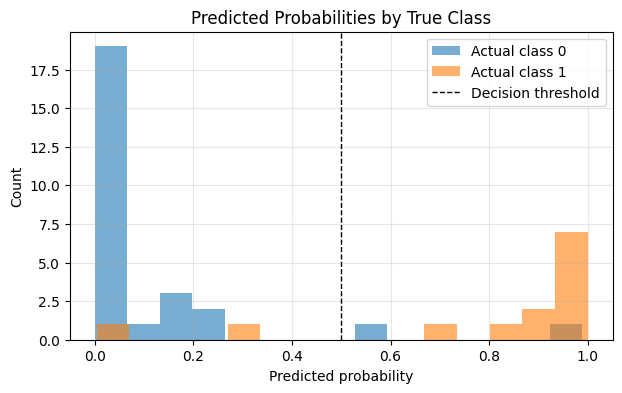

In [13]:
p_test = predict_proba(X_test_s, w_final, b_final)

plt.figure(figsize=(7, 4))
plt.hist(p_test[y_test == 0], bins=15, alpha=0.6, label="Actual class 0")
plt.hist(p_test[y_test == 1], bins=15, alpha=0.6, label="Actual class 1")
plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities by True Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Try It Yourself

Ideas to extend this notebook for your class:

- **Different random seeds for initialisation** — confirm everyone converges to essentially the same weights, since binary cross-entropy loss for logistic regression is also convex (one global minimum), just like MSE was for linear regression.
- **Learning rate experiments** — try `lr=0.01` (slow), `lr=0.5` (used above), and `lr=10` (likely unstable). Plot the loss curve for each.
- **Change the decision threshold** away from 0.5 — see how precision and recall trade off against each other.
- **Skip standardisation** — rerun gradient descent directly on raw `X_train` and see how much slower convergence becomes.
- **Make the classes less separable** — increase the noise in label generation (e.g. shrink `true_w`) and see how test accuracy and the loss curve change.